In [52]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_1D.csv',
                     delimiter=',',
                     skip_header=1)

X = iris[:, :1]
y = iris[:, 1]
N = 6

# intercept = np.ones((X.shape[0], 1))
# X = np.concatenate((intercept, X), axis=1)
X = np.hstack((np.ones((X.shape[0], 1)), X))

# shuffle
inds = np.arange(X.shape[0])
np.random.shuffle(inds)

X = X[inds]
y = y[inds]

print(X.shape)
print(y.shape)

(6, 2)
(6,)


In [53]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def predict(x, theta):
    y_hat = sigmoid_function(np.dot(x, theta))
    return y_hat

def loss_function(y_hat, y):
    return (y_hat - y)**2

def compute_gradient(x, y_hat, y):
    return 2*x*(y_hat-y)*y_hat*(1-y_hat)

In [60]:
lr=0.31
num_iter=5000

theta = np.array([0.1, 5])
losses = []
accs = []

for _ in range(num_iter):
    # for each sample
    for i in range(N):
        # get a sample
        xi = X[i]
        yi = y[i]

        # predict
        y_hat = predict(xi, theta)

        # compute loss
        loss = loss_function(y_hat, yi)

        # compute gradient and update
        gradient = compute_gradient(xi, y_hat, yi)
        theta -= lr*gradient

        # debug
        losses.append(loss)

    # accuracy for training
    preds = predict(X, theta).round()
    acc = (preds == y).mean()
    accs.append(acc)


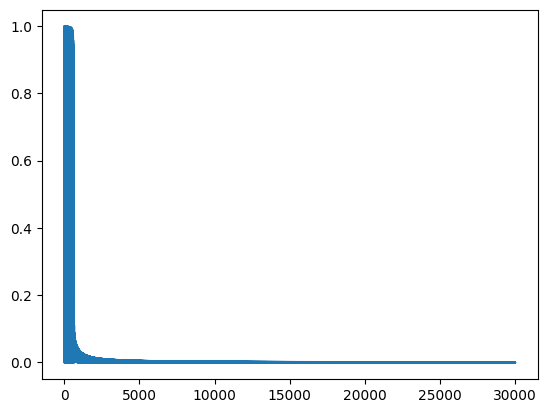

'\nPlot nhìn không smooth vì ta train với 1 sample\n(mục tiêu tối ưu một lúc 6 sample)\ntính nhiễu cao\n'

In [63]:
# plot loss
plt.plot(losses)
plt.show()

'''
Plot nhìn không smooth vì ta train với 1 sample
(mục tiêu tối ưu một lúc 6 sample)
tính nhiễu cao
'''

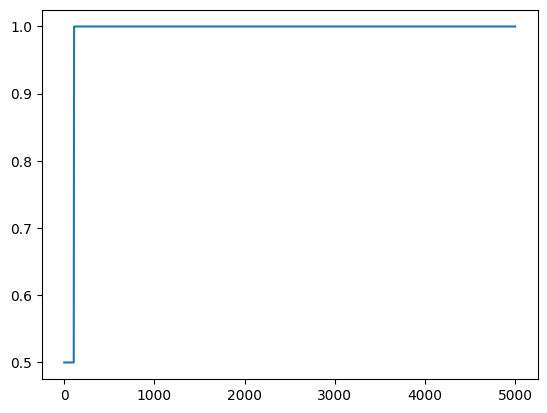

In [64]:
plt.plot(accs)
plt.show()

In [65]:
preds = predict(X, theta).round()
print(y)
print(preds)

[0. 0. 1. 0. 1. 1.]
[0. 0. 1. 0. 1. 1.]
